<a href="https://colab.research.google.com/github/Nandini-Shivappa/PowerCo-Customer-Churn-Analysis-/blob/main/PowerCo_Custtomer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data loading

### Subtask:
Load the provided CSV files into pandas DataFrames.


**Reasoning**:
Load the two csv files into pandas dataframes and display the first 5 rows.



In [ ]:
import pandas as pd

try:
    price_df = pd.read_csv('price_data (1).csv')
    display(price_df.head())
    client_df = pd.read_csv('client_data (1).csv')
    display(client_df.head())
except FileNotFoundError:
    print("Error: One or both of the CSV files were not found.")
except pd.errors.ParserError:
    print("Error: There was an issue parsing one or both of the CSV files. Please check their format.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


## Data exploration

### Subtask:
Explore and understand the characteristics of the loaded datasets.


**Reasoning**:
Analyze the shape, data types, and unique value counts for both dataframes.



In [ ]:
print("Price Data Shape:", price_df.shape)
print("Client Data Shape:", client_df.shape)

print("\nPrice Data Data Types:\n", price_df.dtypes)
print("\nClient Data Data Types:\n", client_df.dtypes)

print("\nPrice Data Unique Value Counts:\n", price_df.nunique())
print("\nClient Data Unique Value Counts:\n", client_df.nunique())

print("\nInitial Observations:")

print("Potential Issues/Areas for Attention:")
print("- The 'price_date' column in price_df needs to be converted to datetime.")
print("- The 'date_activ', 'date_end', 'date_modif_prod', and 'date_renewal' columns in client_df need to be converted to datetime.")
print("- Investigate 'channel_sales' in client_df, as it may contain inconsistent values.")

Price Data Shape: (193002, 8)
Client Data Shape: (14606, 26)

Price Data Data Types:
 id                     object
price_date             object
price_off_peak_var    float64
price_peak_var        float64
price_mid_peak_var    float64
price_off_peak_fix    float64
price_peak_fix        float64
price_mid_peak_fix    float64
dtype: object

Client Data Data Types:
 id                                 object
channel_sales                      object
cons_12m                            int64
cons_gas_12m                        int64
cons_last_month                     int64
date_activ                         object
date_end                           object
date_modif_prod                    object
date_renewal                       object
forecast_cons_12m                 float64
forecast_cons_year                  int64
forecast_discount_energy          float64
forecast_meter_rent_12m           float64
forecast_price_energy_off_peak    float64
forecast_price_energy_peak        float64
fore

## Data analysis

### Subtask:
Calculate descriptive statistics and analyze unique values in categorical columns.


**Reasoning**:
Calculate descriptive statistics for numerical columns and analyze unique values in categorical columns.



In [ ]:
print("Descriptive Statistics for price_df:\n", price_df.describe())
print("\nDescriptive Statistics for client_df:\n", client_df.describe())

for col in price_df.select_dtypes(include=['object']).columns:
    print(f"\nUnique values and counts for {col} in price_df:\n{price_df[col].value_counts()}")

for col in client_df.select_dtypes(include=['object']).columns:
    print(f"\nUnique values and counts for {col} in client_df:\n{client_df[col].value_counts()}")

Descriptive Statistics for price_df:
        price_off_peak_var  price_peak_var  price_mid_peak_var  \
count       193002.000000   193002.000000       193002.000000   
mean             0.141027        0.054630            0.030496   
std              0.025032        0.049924            0.036298   
min              0.000000        0.000000            0.000000   
25%              0.125976        0.000000            0.000000   
50%              0.146033        0.085483            0.000000   
75%              0.151635        0.101673            0.072558   
max              0.280700        0.229788            0.114102   

       price_off_peak_fix  price_peak_fix  price_mid_peak_fix  
count       193002.000000   193002.000000       193002.000000  
mean            43.334477       10.622875            6.409984  
std              5.410297       12.841895            7.773592  
min              0.000000        0.000000            0.000000  
25%             40.728885        0.000000            0.0

**Reasoning**:
Based on the descriptive statistics and unique value counts, convert date columns to datetime objects and handle potential errors gracefully.  Also, further analyze the `channel_sales` column in `client_df` for inconsistencies.



In [ ]:
import pandas as pd

date_columns_price = ['price_date']
for col in date_columns_price:
    try:
        price_df[col] = pd.to_datetime(price_df[col], errors='coerce')
    except Exception as e:
        print(f"Error converting {col} in price_df: {e}")

date_columns_client = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in date_columns_client:
    try:
        client_df[col] = pd.to_datetime(client_df[col], errors='coerce')
    except Exception as e:
        print(f"Error converting {col} in client_df: {e}")

print("\nFurther analysis of channel_sales in client_df:")
print(client_df['channel_sales'].value_counts(normalize=True) * 100)  # Display percentage
missing_channel_sales = client_df[client_df['channel_sales'] == 'MISSING']
print(f"\nNumber of entries with 'MISSING' channel_sales: {len(missing_channel_sales)}")



Further analysis of channel_sales in client_df:
channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    46.241271
MISSING                             25.503218
lmkebamcaaclubfxadlmueccxoimlema    12.618102
usilxuppasemubllopkaafesmlibmsdf     9.413939
ewpakwlliwisiwduibdlfmalxowmwpci     6.113926
sddiedcslfslkckwlfkdpoeeailfpeds     0.075312
epumfxlbckeskwekxbiuasklxalciiuu     0.020540
fixdbufsefwooaasfcxdxadsiekoceaa     0.013693
Name: proportion, dtype: float64

Number of entries with 'MISSING' channel_sales: 3725


## Data visualization

### Subtask:
Visualize the distributions of key numerical features and identify potential outliers or unusual patterns.


**Reasoning**:
Visualize the distributions of key numerical features in `price_df` and `client_df` using histograms and box plots. Identify potential outliers. Handle the "MISSING" values in the `channel_sales` column of `client_df` before visualizing it.



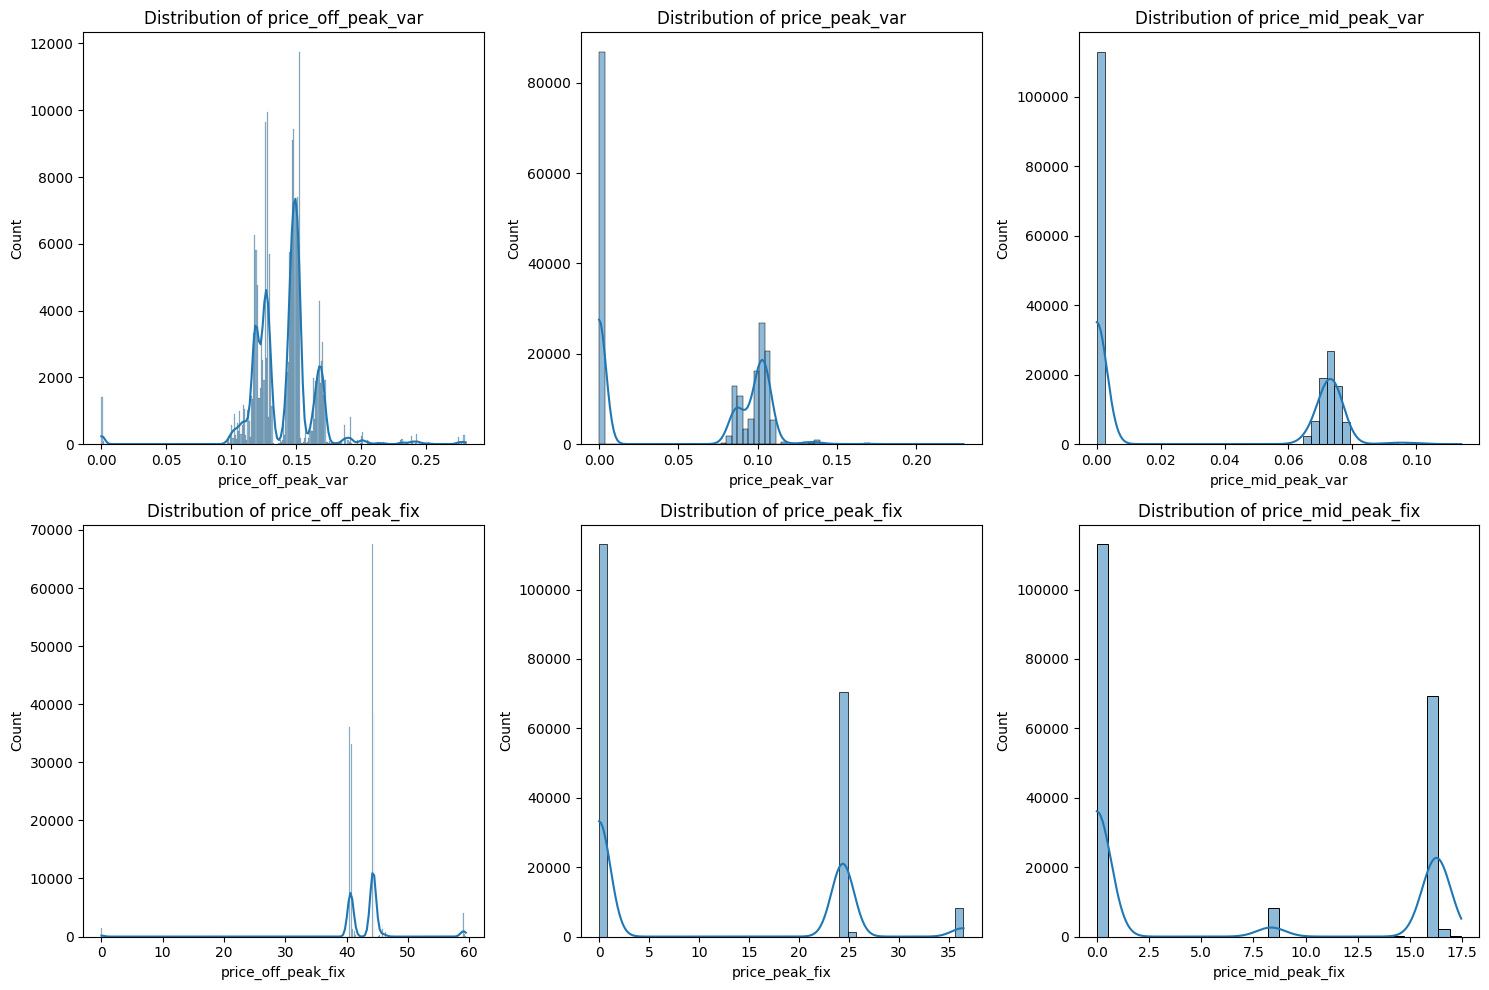

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_price = ['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
                        'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_price):
    plt.subplot(2, 3, i + 1)
    sns.histplot(price_df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


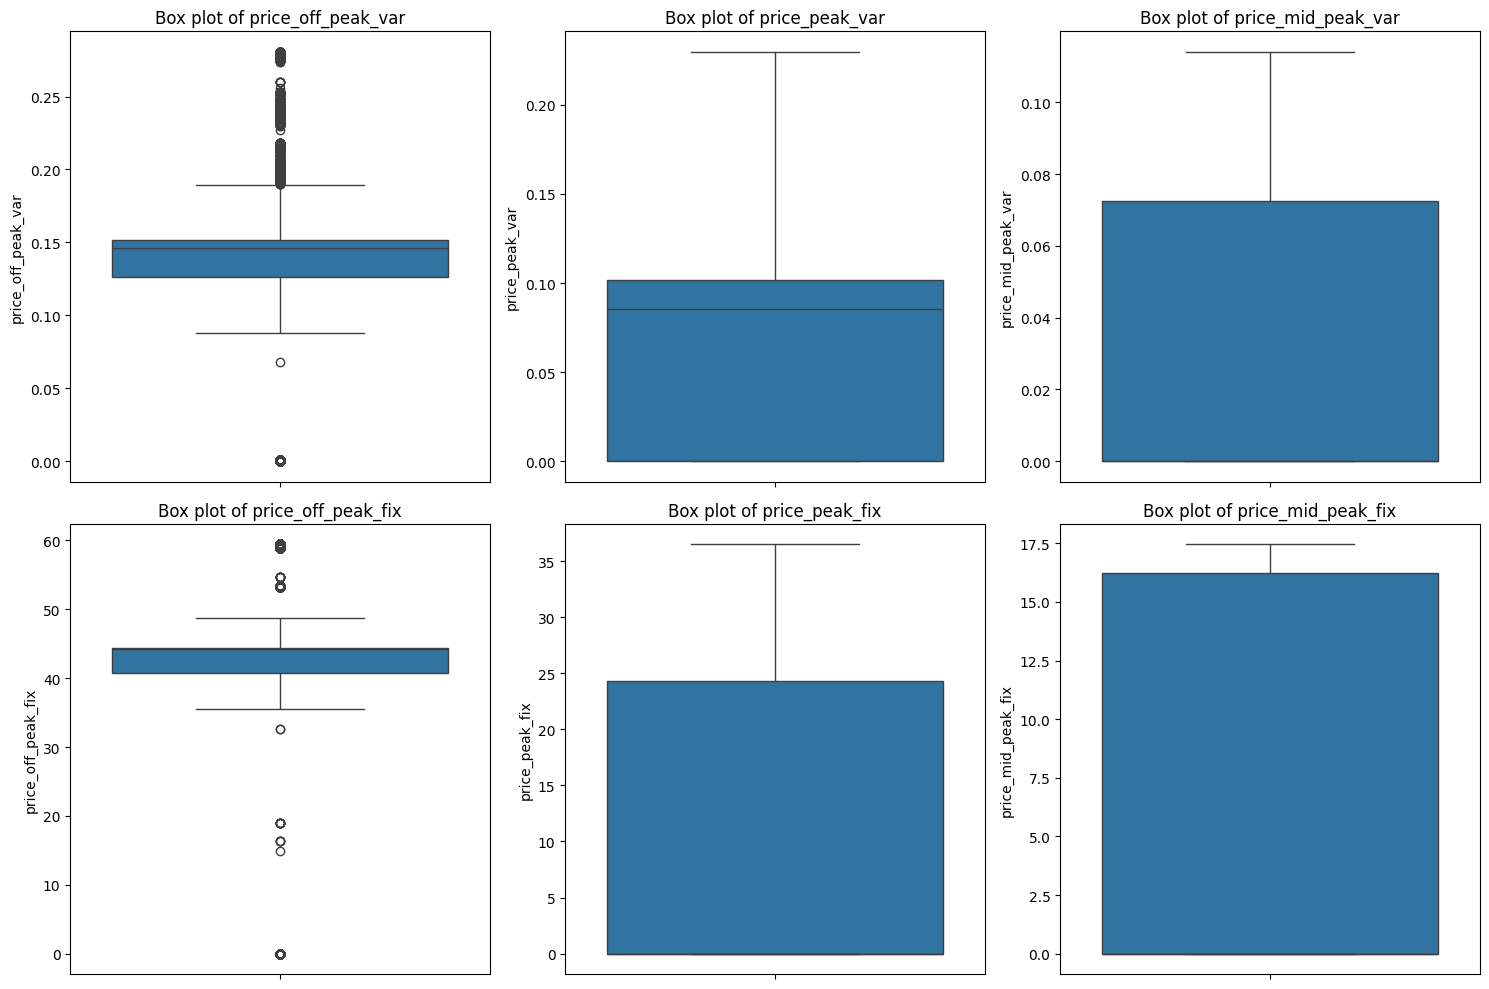

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_price):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=price_df[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

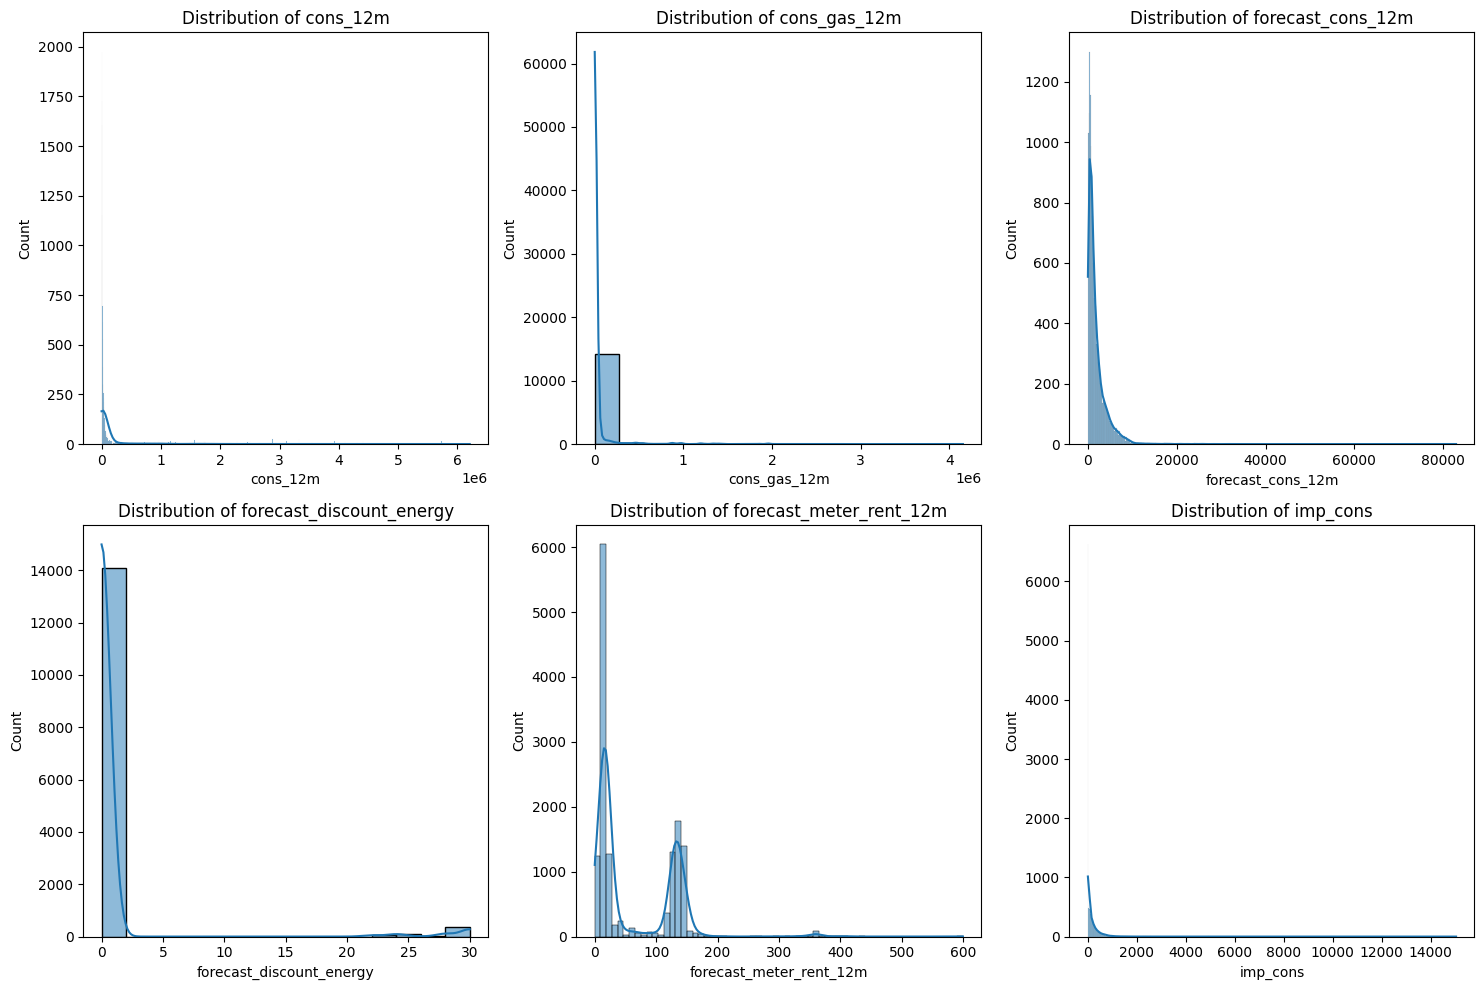

In [ ]:
numerical_cols_client = ['cons_12m', 'cons_gas_12m', 'forecast_cons_12m',
                         'forecast_discount_energy', 'forecast_meter_rent_12m', 'imp_cons']


plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_client):
    plt.subplot(2, 3, i + 1)
    sns.histplot(client_df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

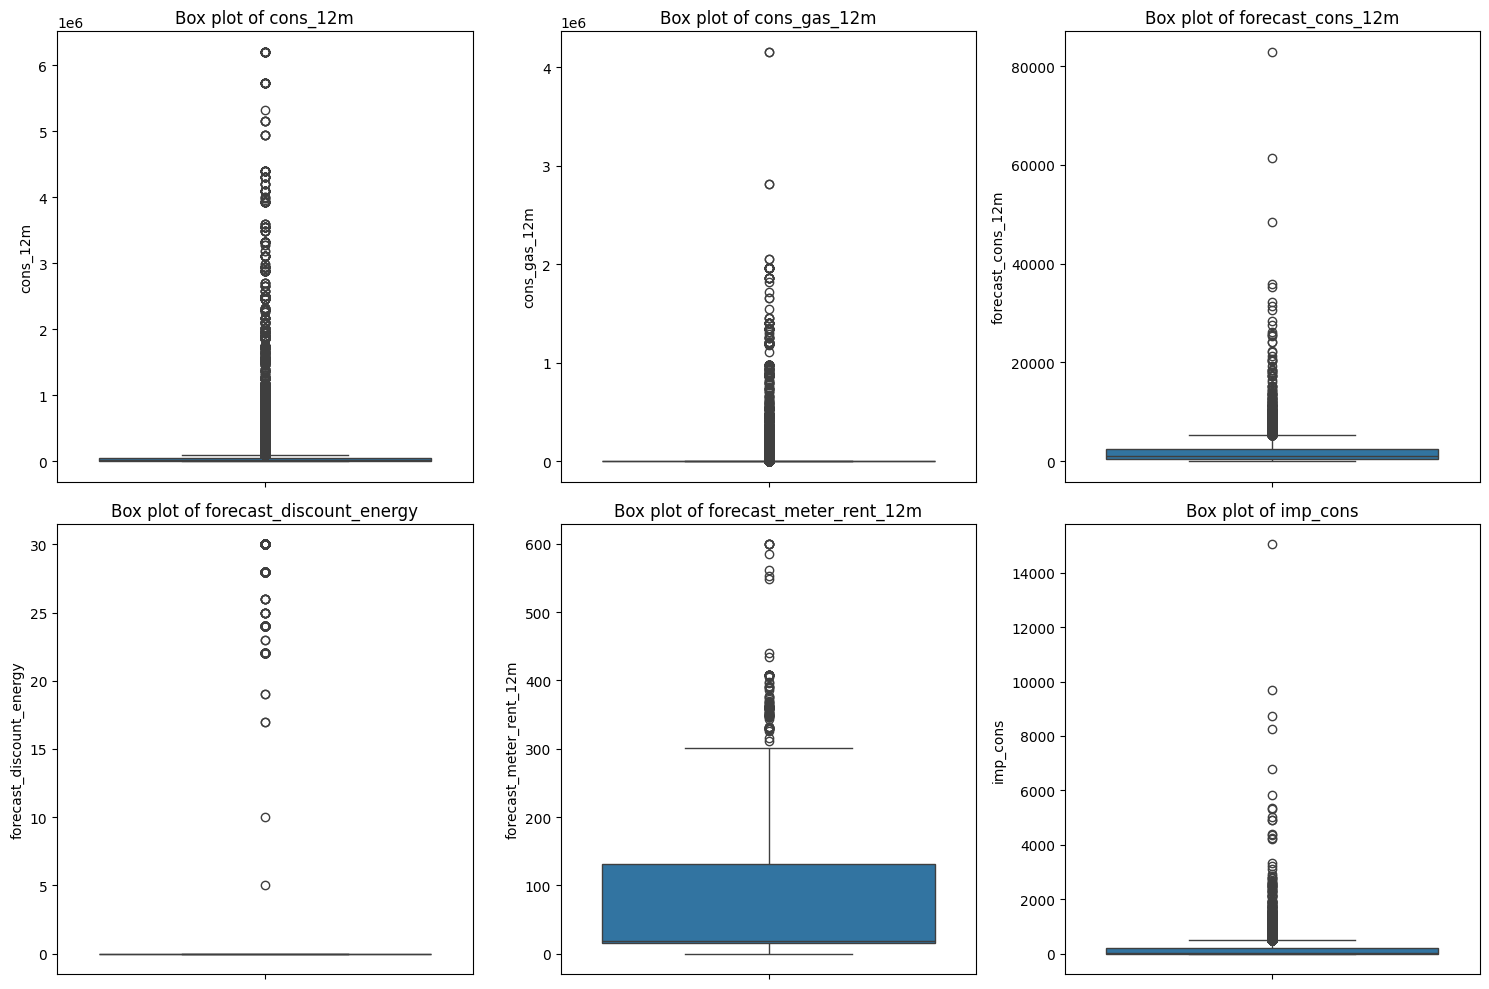

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_client):
  plt.subplot(2, 3, i+1)
  sns.boxplot(y=client_df[col])
  plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

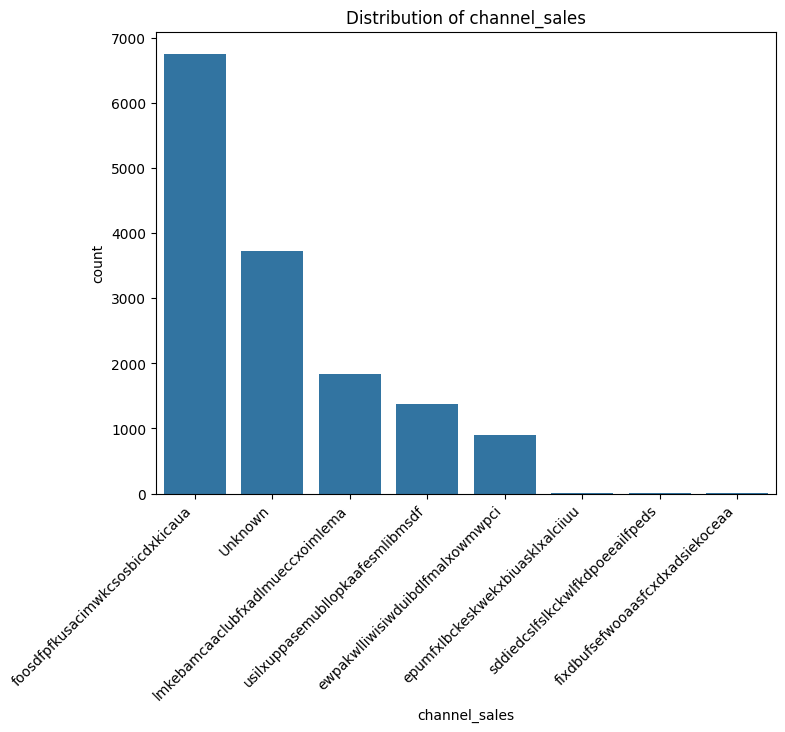

In [ ]:
client_df['channel_sales'] = client_df['channel_sales'].replace('MISSING', 'Unknown')
plt.figure(figsize=(8, 6))
sns.countplot(x='channel_sales', data=client_df)
plt.title('Distribution of channel_sales')
plt.xticks(rotation=45, ha='right')
plt.show()

## Summary:

### Q&A
There are no explicit questions in the task description. However, the hints and instructions implicitly ask for an understanding of the data, potential issues, and key characteristics.  The analysis process addresses these implicit questions.

### Data Analysis Key Findings
* **Data Shapes:** The `price_df` has 193,002 rows and 8 columns, while `client_df` has 14,606 rows and 26 columns.
* **Data Types:** Several date columns were initially identified as 'object' (strings) and were subsequently converted to datetime objects.
* **Unique Values:** The `channel_sales` column in `client_df` contains 8 unique values, including a significant number (3725, or \~25.5\%) of "MISSING" entries.  These missing values were later replaced with "Unknown".
* **Potential Outliers:**  Visualizations (histograms and box plots) of numerical features in both dataframes revealed potential outliers, particularly in columns like `cons_12m` in `client_df`.  Further investigation of these outliers is recommended.
* **Missing Values:** A substantial number of "MISSING" values were found in the `channel_sales` column of the `client_df`.  These have been replaced with 'Unknown' and visualized.


### Insights or Next Steps
* **Data Cleaning:** Focus on handling the outliers identified in the numerical features and further investigate the meaning of the "Unknown" `channel_sales` values.  Consider imputation or removal of outliers based on domain knowledge or further analysis.
* **Feature Engineering:** Explore creating new features from the existing data, such as aggregating or transforming data based on the identified patterns and distributions.  For example, consider extracting the month from the date columns.
